## Load All Libraries

In [1]:
#Import libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import odc.stac
import pystac_client
from odc.stac import load
from pystac.client import Client

## Define the Study Area
In this case it's the area of Ba region.

In [2]:
#Yalelevu AOI imported from asset

aoi = gpd.read_file("/home/jovyan/Soil moisture-Individual Project/Ba.geojson")
aoi = aoi.to_crs("EPSG:4326")
min_lon, min_lat, max_lon, max_lat = aoi.total_bounds

bbox = [min_lon, min_lat, max_lon, max_lat]

In [3]:
aoi.explore()

## Load Sentinel 1 Data
Pre- flood images - 6 months prior to flooding from July to December of 2024.

In [4]:
catalog = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalog)
datetime = "2024-07-01/2024-12-31"


In [5]:
items = client.search(
    collections=["sentinel-1-grd"],
    bbox=bbox,
    datetime=datetime,
    query={
        "sar:instrument_mode": {"eq": "IW"},
        "sat:orbit_state": {"eq": "ascending"},
        "s1:orbit_source": {"eq": "RESORB"}
    }
).item_collection()

In [6]:
items

In [7]:
# Load the VV and VH
pre_ds = load(
    items,
    bands=["vv", "vh"],
    bbox=bbox,
    groupby="id"
)    

In [24]:
import numpy as np
import xarray as xr
from scipy.ndimage import uniform_filter

# -----------------------------
# Lee Filter
# -----------------------------
def lee_filter(img, size=7):

    mean = uniform_filter(img, size)
    mean_sq = uniform_filter(img**2, size)

    variance = mean_sq - mean**2
    overall_var = np.nanmean(variance)

    weights = variance / (variance + overall_var)

    return mean + weights * (img - mean)

# -----------------------------
# PRE-FLOOD MEDIAN COMPOSITE
# -----------------------------
pre_vh = pre_ds.vh.median(dim="time")
pre_vv = pre_ds.vv.median(dim="time")

# -----------------------------
# APPLY LEE FILTER
# -----------------------------
pre_vh_filtered = xr.DataArray(
    lee_filter(pre_vh.values, size=7),
    coords=pre_vh.coords,
    dims=pre_vh.dims
)

pre_vv_filtered = xr.DataArray(
    lee_filter(pre_vv.values, size=7),
    coords=pre_vv.coords,
    dims=pre_vv.dims
)

# -----------------------------
# CONVERT TO dB
# -----------------------------
pre_vh_db = 10 * np.log10(pre_vh_filtered.clip(min=1e-6))
pre_vv_db = 10 * np.log10(pre_vv_filtered.clip(min=1e-6))

# -----------------------------
# VV/VH RATIO
# -----------------------------
pre_ratio = pre_vv_db - pre_vh_db

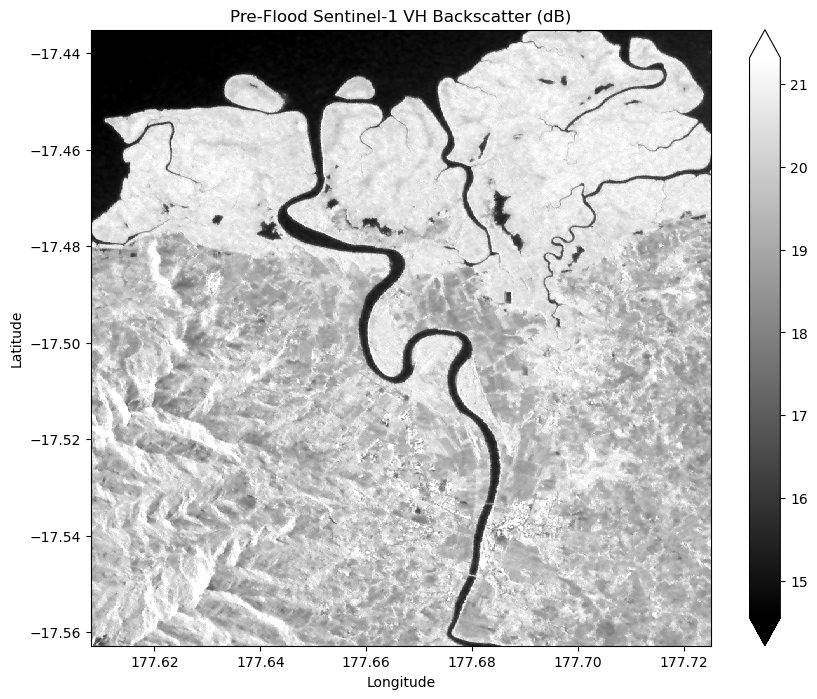

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

pre_vh_db.plot(
    cmap="gray",
    robust=True
)

plt.title("Pre-Flood Sentinel-1 VH Backscatter (dB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

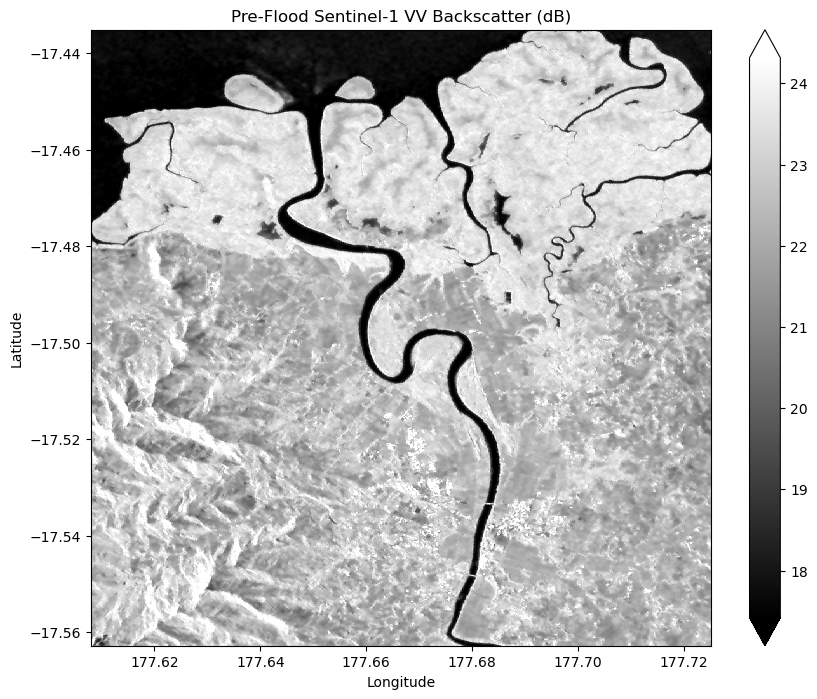

In [26]:
plt.figure(figsize=(10,8))

pre_vv_db.plot(
    cmap="gray",
    robust=True
)

plt.title("Pre-Flood Sentinel-1 VV Backscatter (dB)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [27]:
pre_vh_db.rio.to_raster("pre_vh_db.tif")
pre_vv_db.rio.to_raster("pre_vv_db.tif")

In [8]:
# ------------------
# Median composites
# ------------------
pre_vv = pre_ds.vv.median(dim="time")
pre_vh = pre_ds.vh.median(dim="time")

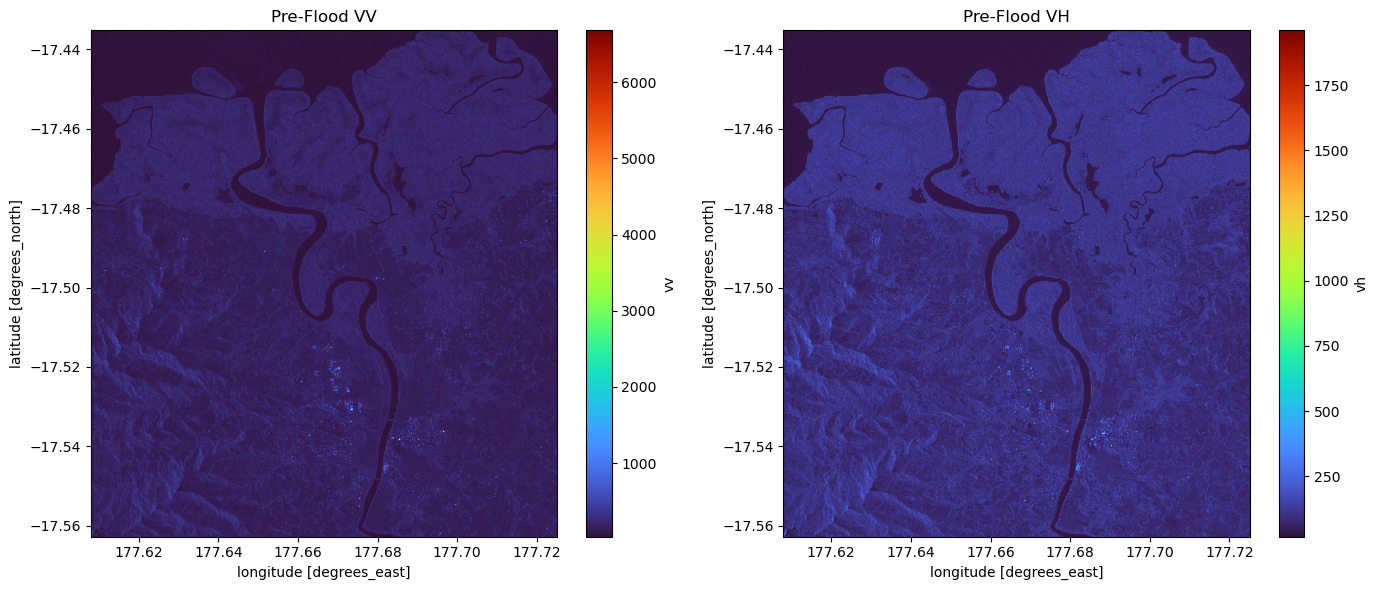

In [9]:
# ------------------
# Plot results
# ------------------
# Plot side-by-side
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

pre_vv.plot(
ax=ax[0],
cmap="turbo"
)

ax[0].set_title("Pre-Flood VV")
pre_vh.plot(
ax=ax[1],
cmap="turbo"
)

ax[1].set_title("Pre-Flood VH")

plt.tight_layout()
plt.show()

In [10]:
#As we can that VH polarization is more needed for more vegetatuion structure, it can help identify the flooded vegetation (e.g, crops mangroves....)

## Normalize
Here, we will normalise the VH image.

In [11]:
# Pre-flood VH
pre_vh = pre_ds.vh.median(dim="time")
pre_vh_norm = (
(pre_vh - pre_vh.min()) /
(pre_vh.max() - pre_vh.min())
)

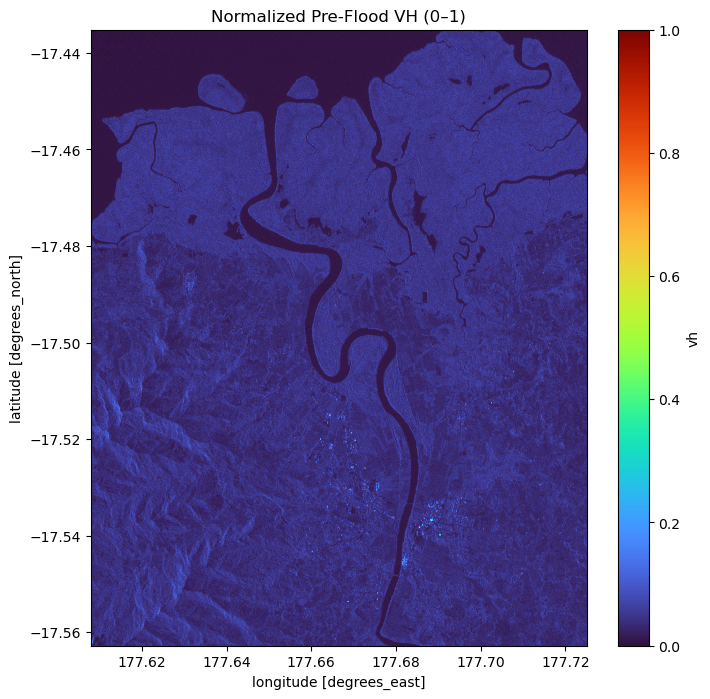

In [12]:
#Visualize the plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
pre_vh_norm.plot(
    cmap="turbo",
    vmin=0,
    vmax=1
)
plt.title("Normalized Pre-Flood VH (0–1)")
plt.show()

## Speckle Filtering
Applying speckle filters on the normalized image.

In [13]:
# Define the lee filter functin
import numpy as np
from scipy.ndimage import uniform_filter

def lee_filter(img, size=2):
    img = img.astype(np.float32)

    mean = uniform_filter(img, size)
    mean_sq = uniform_filter(img**2, size)

    variance = mean_sq - mean**2

    overall_var = np.nanvar(img)

    weights = variance / (variance + overall_var)

    lee = mean + weights * (img - mean)

    return lee

In [14]:
#Rename the Pre VH Norm
vh_lee = pre_vh_norm.copy()

vh_lee.data = lee_filter(
    pre_vh_norm.values,
    size=7
)

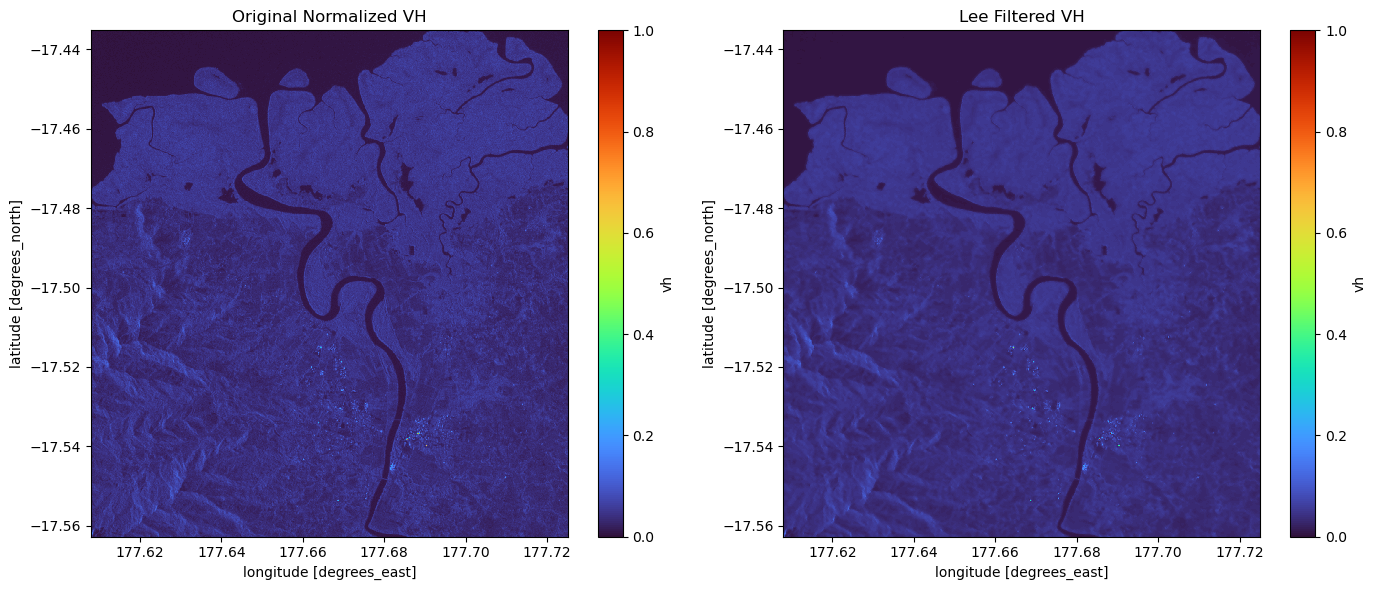

In [15]:
#Visualize

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

pre_vh_norm.plot(
    ax=ax[0],
    cmap="turbo",
    vmin=0,
    vmax=1
)
ax[0].set_title("Original Normalized VH")

vh_lee.plot(
    ax=ax[1],
    cmap="turbo",
    vmin=0,
    vmax=1
)
ax[1].set_title("Lee Filtered VH")

plt.tight_layout()
plt.show()

In [16]:
# Test for Gamma filter

In [17]:
import numpy as np
from scipy.ndimage import uniform_filter

def gamma_map_filter(img, size=2, enl=1):
    img = img.astype(np.float32)

    mean = uniform_filter(img, size)
    mean_sq = uniform_filter(img**2, size)

    var = mean_sq - mean**2

    ci = np.sqrt(var) / (mean + 1e-12)
    cu = 1 / np.sqrt(enl)

    w = np.maximum(0, (ci**2 - cu**2) / (ci**2 + 1e-12))

    filtered = mean + w * (img - mean)

    return filtered

In [18]:
vh_gamma = pre_vh_norm.copy()

vh_gamma.data = gamma_map_filter(
    pre_vh_norm.values,
    size=3,
    enl=1
)

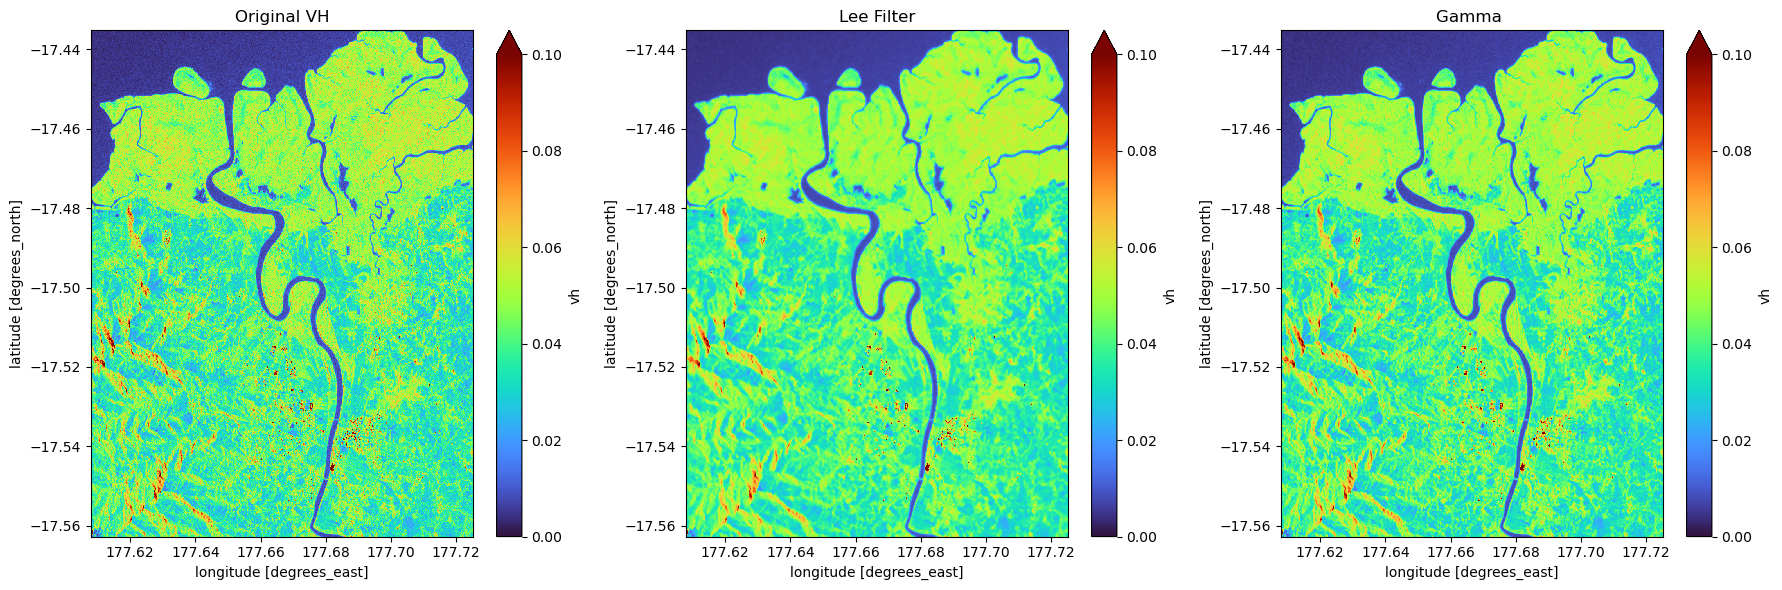

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

pre_vh_norm.plot(
    ax=ax[0],
    cmap="turbo",
    vmin=0,
    vmax=0.1
)
ax[0].set_title("Original VH")

vh_lee.plot(
    ax=ax[1],
    cmap="turbo",
    vmin=0,
    vmax=0.1
)
ax[1].set_title("Lee Filter")

vh_gamma.plot(
    ax=ax[2],
    cmap="turbo",
    vmin=0,
    vmax=0.1
)
ax[2].set_title("Gamma ")

plt.tight_layout()
plt.show()

In [20]:
print("Original:", float(pre_vh_norm.std()))
print("Lee:", float(vh_lee.std()))
print("Gamma:", float(vh_gamma.std()))

Original: 0.016058152471787063
Lee: 0.014478668570518494
Gamma: 0.014913948252797127


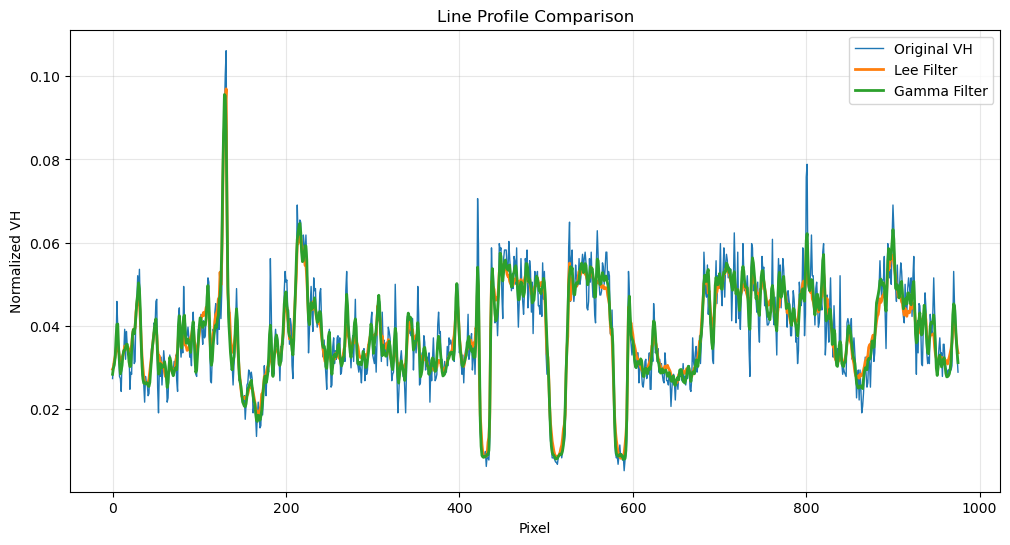

In [21]:
#Lets plot a Line graph
import matplotlib.pyplot as plt

# Middle row
row = pre_vh_norm.shape[0] // 2

orig_profile = pre_vh_norm.values[row, :]
lee_profile = vh_lee.values[row, :]
gamma_profile = vh_gamma.values[row, :]

plt.figure(figsize=(12, 6))

plt.plot(orig_profile, label="Original VH", linewidth=1)
plt.plot(lee_profile, label="Lee Filter", linewidth=2)
plt.plot(gamma_profile, label="Gamma Filter", linewidth=2)

plt.xlabel("Pixel")
plt.ylabel("Normalized VH")
plt.title("Line Profile Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

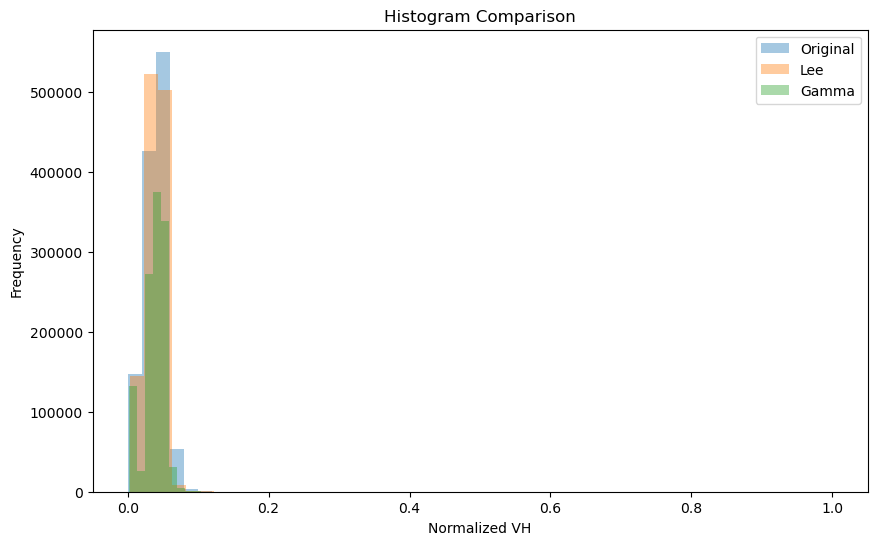

In [22]:
#Plot the histogram
plt.figure(figsize=(10,6))

pre_vh_norm.plot.hist(
    bins=50,
    alpha=0.4,
    label="Original"
)

vh_lee.plot.hist(
    bins=50,
    alpha=0.4,
    label="Lee"
)

vh_gamma.plot.hist(
    bins=50,
    alpha=0.4,
    label="Gamma"
)

plt.xlabel("Normalized VH")
plt.ylabel("Frequency")
plt.title("Histogram Comparison")
plt.legend()

plt.show()

In [23]:
import rioxarray
vh_gamma.rio.to_raster("Ba.tif")